# Théorie des valeurs extrêmes — Estimation du seuil de grave

## Introduction (résumé)

Ce notebook présente les étapes de travail et les choix techniques, avec une progression section par section jusqu'aux résultats exploitables pour la suite du projet.

Le sommaire ci-dessous permet d'accéder directement aux sections principales.

## Sommaire cliquable

- [1. Contexte](#sec-1-contexte)
- [2. Imports et chargement](#sec-2-imports-et-chargement)
- [3. Statistiques descriptives des sinistres](#sec-3-statistiques-descriptives-des-sinistres)
- [4. Analyse graphique](#sec-4-analyse-graphique)
- [5. Estimateur de Hill](#sec-5-estimateur-de-hill)
- [6. Estimateur de Pickands](#sec-6-estimateur-de-pickands)
- [7. Méthode des moments](#sec-7-methode-des-moments)
- [8. Mean Residual Life Plot (MRLP)](#sec-8-mean-residual-life-plot-mrlp)
- [9. Sélection du seuil par AIC (GPD)](#sec-9-selection-du-seuil-par-aic-gpd)
- [10. Stabilité des paramètres GPD](#sec-10-stabilite-des-parametres-gpd)
- [11. Ajustement GPD final](#sec-11-ajustement-gpd-final)
- [12. Décomposition sous-crête / sur-crête](#sec-12-decomposition-sous-crete-sur-crete)
- [13. Ajustement avec les plafonnés — GPD et Fréchet avec censure](#sec-13-ajustement-avec-les-plafonnes-gpd-et-frechet-avec-censure)
- [15. Synthèse](#sec-15-synthese)

<a id="sec-1-contexte"></a>

## 1. Contexte

L'objectif de ce notebook est de déterminer un **seuil de grave** : le montant de CM au-delà duquel un sinistre est considéré comme "grave" et doit être modélisé séparément (loi de queue lourde type GPD) plutôt qu'avec le reste des attritionnels.

On mobilise plusieurs méthodes classiques de la théorie des valeurs extrêmes :
- **Hill** et **Pickands** : estimateurs de l'indice de queue ξ
- **Méthode des moments** : estimateur alternatif de ξ
- **MRLP** (Mean Residual Life Plot) : détection visuelle du seuil
- **AIC GPD** : sélection du seuil par qualité d'ajustement
- **Stabilité GPD** : vérification que les paramètres sont stables

On croise ensuite tous les résultats pour choisir un seuil robuste.

<a id="sec-2-imports-et-chargement"></a>

## 2. Imports et chargement

### 2.1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import genpareto, kstest
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis
from scipy.optimize import minimize
from scipy.stats import genpareto
from scipy.stats import genextreme
from scipy.optimize import approx_fprime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

### 2.2. Chargement

In [2]:
train = pd.read_csv("new_data/train_engineered.csv")

sinistres = train[train['CM'] > 0]['CM'].copy()
plafond = 500000

print(f"Contrats totaux     : {len(train):,}")
print(f"Sinistres (CM > 0)  : {len(sinistres):,}")
print(f"Plafonnés (= 500k)  : {(sinistres >= plafond).sum()}")
print(f"Taux de sinistres   : {len(sinistres)/len(train)*100:.2f}%")

Contrats totaux     : 383,610
Sinistres (CM > 0)  : 2,352
Plafonnés (= 500k)  : 20
Taux de sinistres   : 0.61%


<a id="sec-3-statistiques-descriptives-des-sinistres"></a>

## 3. Statistiques descriptives des sinistres

In [3]:
print(f"{'Statistique':<20} {'Valeur':>15}")
print("-" * 37)
print(f"{'Count':<20} {len(sinistres):>15,}")
print(f"{'Moyenne':<20} {sinistres.mean():>15,.2f}€")
print(f"{'Médiane':<20} {sinistres.median():>15,.2f}€")
print(f"{'Écart-type':<20} {sinistres.std():>15,.2f}€")
print(f"{'Min':<20} {sinistres.min():>15,.2f}€")
print(f"{'Max':<20} {sinistres.max():>15,.2f}€")
print(f"{'Skewness':<20} {skew(sinistres):>15.2f}")
print(f"{'Kurtosis':<20} {kurtosis(sinistres):>15.2f}")

print(f"\nQuantiles clés :")
for q in [0.50, 0.75, 0.90, 0.95, 0.99, 0.995]:
    print(f"  Q{q*100:5.1f}% : {sinistres.quantile(q):>12,.0f}€")

Statistique                   Valeur
-------------------------------------
Count                          2,352
Moyenne                    29,775.08€
Médiane                     1,786.60€
Écart-type                 80,268.51€
Min                             1.00€
Max                       500,000.00€
Skewness                        3.83
Kurtosis                       15.48

Quantiles clés :
  Q 50.0% :        1,787€
  Q 75.0% :       10,005€
  Q 90.0% :       82,992€
  Q 95.0% :      199,273€
  Q 99.0% :      445,775€
  Q 99.5% :      500,000€


Distribution très asymétrique (skewness élevé, kurtosis élevé) — signature classique d'une queue lourde. La médiane est très inférieure à la moyenne, confirmant que quelques sinistres extrêmes tirent tout vers le haut. Les quantiles montrent une accélération nette au-delà du Q90 — c'est dans cette zone qu'on cherchera le seuil de grave.


<a id="sec-4-analyse-graphique"></a>

## 4. Analyse graphique

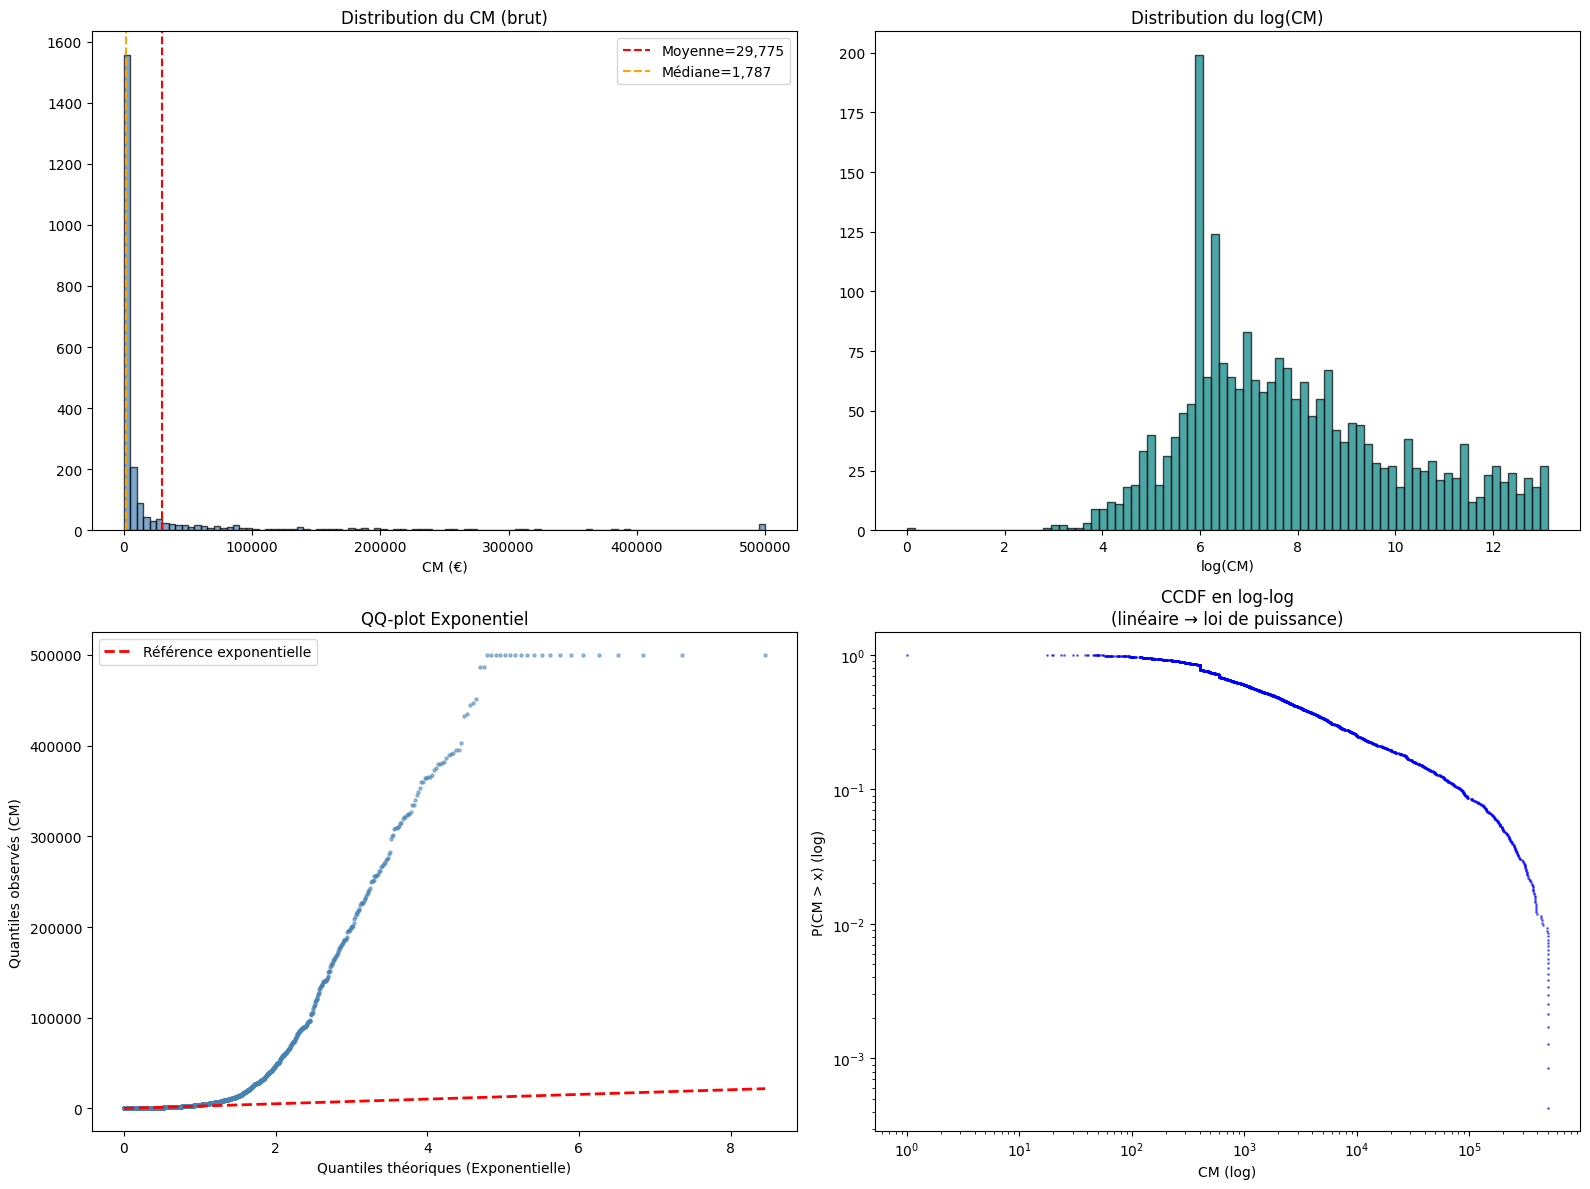

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogramme brut
axes[0, 0].hist(sinistres, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(sinistres.mean(), color='red', linestyle='--', label=f'Moyenne={sinistres.mean():,.0f}')
axes[0, 0].axvline(sinistres.median(), color='orange', linestyle='--', label=f'Médiane={sinistres.median():,.0f}')
axes[0, 0].set_title('Distribution du CM (brut)')
axes[0, 0].set_xlabel('CM (€)')
axes[0, 0].legend()

# Histogramme log
axes[0, 1].hist(np.log(sinistres), bins=80, color='teal', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribution du log(CM)')
axes[0, 1].set_xlabel('log(CM)')

# QQ-plot exponentiel
sorted_data = np.sort(sinistres)
n = len(sorted_data)
theoretical_quantiles = -np.log(1 - (np.arange(1, n + 1) - 0.5) / n)

axes[1, 0].scatter(theoretical_quantiles, sorted_data, s=5, alpha=0.5, color='steelblue')
slope = np.median(sorted_data) / np.median(theoretical_quantiles)
axes[1, 0].plot([0, theoretical_quantiles.max()], [0, slope * theoretical_quantiles.max()],
                'r--', linewidth=2, label='Référence exponentielle')
axes[1, 0].set_title('QQ-plot Exponentiel')
axes[1, 0].set_xlabel('Quantiles théoriques (Exponentielle)')
axes[1, 0].set_ylabel('Quantiles observés (CM)')
axes[1, 0].legend()

# CCDF log-log
sorted_vals = np.sort(sinistres.values)[::-1]
ccdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
axes[1, 1].loglog(sorted_vals, ccdf, 'b.', markersize=2, alpha=0.5)
axes[1, 1].set_title('CCDF en log-log\n(linéaire → loi de puissance)')
axes[1, 1].set_xlabel('CM (log)')
axes[1, 1].set_ylabel('P(CM > x) (log)')

plt.tight_layout()
plt.show()

Quatre signaux convergents vers une queue lourde :
- **Histogramme brut** : écrasé vers 0, la moyenne (29 775€) est 17x supérieure à la médiane (1 787€). Quelques sinistres extrêmes dominent.
- **log(CM)** : distribution étalée de 0 à 13, avec un mode autour de 6-7 (CM ~ 400-1000€) et une queue qui s'étire jusqu'à 13 (500k). Pas de coupure nette entre attritionnels et graves — c'est un continuum.
- **QQ-plot exponentiel** : décrochage massif vers le haut à partir des quantiles théoriques ~2-3. Si la distribution était exponentielle (queue légère), les points suivraient la droite rouge. Le décrochage vers le haut confirme une queue **beaucoup plus lourde** que l'exponentielle.
- **CCDF log-log** : la décroissance est quasi-linéaire entre 10³ et 10⁵ — signature d'une loi de puissance (domaine de Fréchet). Le spike à droite (500k) est l'effet du plafonnement.

Tous les indicateurs pointent vers une queue lourde de type Fréchet (ξ > 0). On passe aux estimateurs formels.

<a id="sec-5-estimateur-de-hill"></a>

## 5. Estimateur de Hill

L'estimateur de Hill estime l'indice de queue ξ en utilisant les k plus grandes observations. On le trace en fonction de k : un **plateau** indique la zone où l'estimation est stable, et le seuil correspondant.

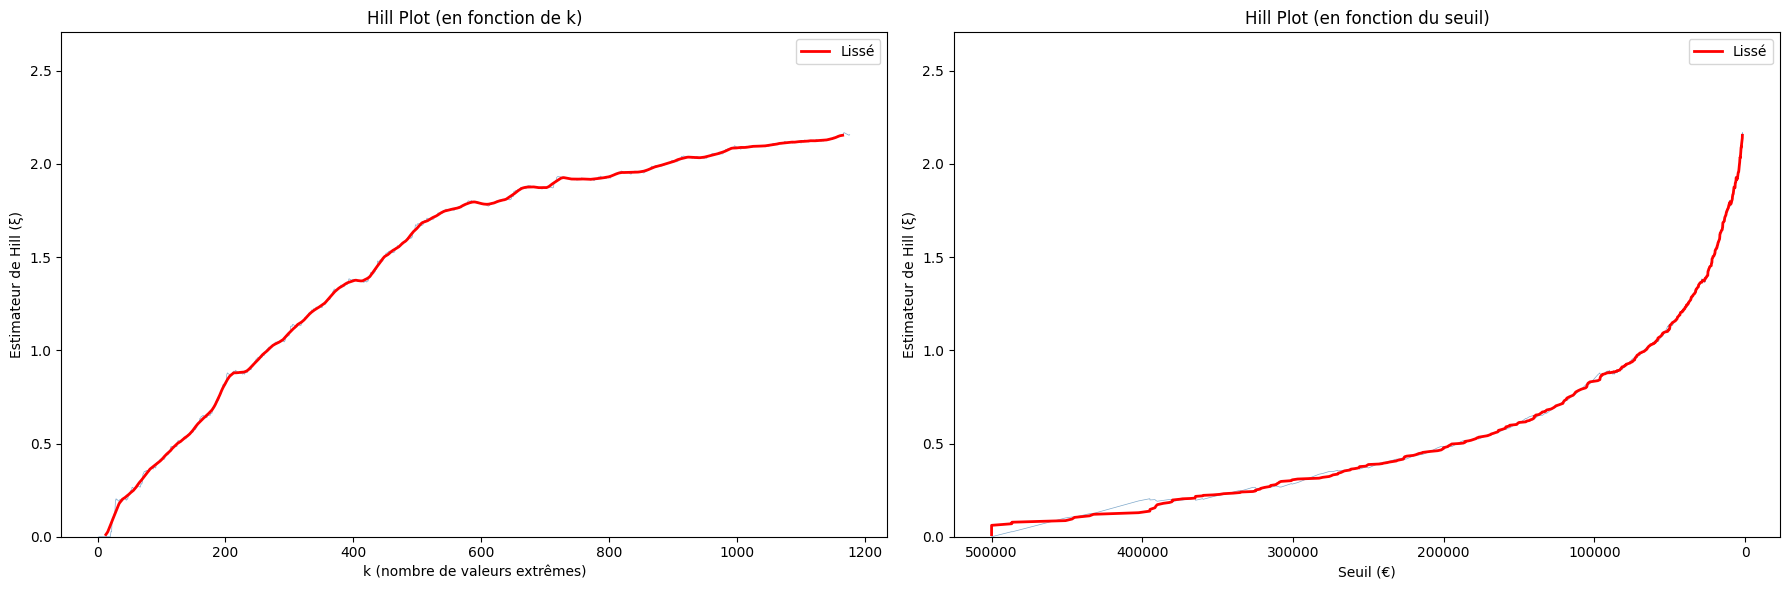

Estimateur de Hill (médiane zone stable) : ξ ≈ 0.4467
Seuil correspondant (k=100)              : 228,976€


In [5]:
sorted_desc = np.sort(sinistres.values)[::-1]
n = len(sorted_desc)

k_max = min(n - 1, int(n * 0.5))
k_values = np.arange(2, k_max + 1)
hill_values = []
threshold_values = []

for k in k_values:
    log_ratios = np.log(sorted_desc[:k-1] / sorted_desc[k-1])
    hill_values.append(np.mean(log_ratios))
    threshold_values.append(sorted_desc[k-1])

hill_values = np.array(hill_values)
threshold_values = np.array(threshold_values)

# Lissage
window = max(10, len(hill_values) // 50)
smoothed = pd.Series(hill_values).rolling(window=window, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Hill en fonction de k
axes[0].plot(k_values, hill_values, color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].plot(k_values, smoothed, color='red', linewidth=2, label='Lissé')
axes[0].set_title('Hill Plot (en fonction de k)')
axes[0].set_xlabel('k (nombre de valeurs extrêmes)')
axes[0].set_ylabel('Estimateur de Hill (ξ)')
axes[0].legend()
axes[0].set_ylim(0, max(hill_values[:len(hill_values)//2]) * 1.5)

# Hill en fonction du seuil
axes[1].plot(threshold_values, hill_values, color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].plot(threshold_values, smoothed, color='red', linewidth=2, label='Lissé')
axes[1].set_title('Hill Plot (en fonction du seuil)')
axes[1].set_xlabel('Seuil (€)')
axes[1].set_ylabel('Estimateur de Hill (ξ)')
axes[1].legend()
axes[1].invert_xaxis()
axes[1].set_ylim(0, max(hill_values[:len(hill_values)//2]) * 1.5)

plt.tight_layout()
plt.show()

# Valeur au plateau (médiane sur la zone stable)
hill_median = np.median(hill_values[20:200])
print(f"Estimateur de Hill (médiane zone stable) : ξ ≈ {hill_median:.4f}")
print(f"Seuil correspondant (k=100)              : {threshold_values[98]:,.0f}€")

Le Hill plot ne montre pas de plateau franc — l'estimateur croît continûment avec k. C'est typique quand la distribution est un mélange (attritionnels + graves) plutôt qu'une pure loi de Pareto. La zone la plus stable se situe autour de k = 20-200 (seuils entre ~100k et ~400k€), avec ξ ≈ 0.45.

ξ > 0 confirme une queue lourde (domaine de Fréchet). Mais Hill seul ne suffit pas pour fixer le seuil — on croise avec les autres méthodes.

### 5.1. Sensibilité de l'estimateur de Hill à la plage de k

Le choix de la plage k=20-200 est visuel. On vérifie que l'estimation de ξ est stable sur différentes plages.

In [6]:
print(f"Sensibilité de ξ_Hill à la plage de k :\n")
print(f"  {'Plage k':<20} {'ξ_Hill (médiane)':>18} {'ξ_Hill (mean)':>18} {'Seuil moyen':>15}")
print(f"  {'-'*75}")

for k_start, k_end in [(5, 50), (10, 100), (20, 200), (50, 300), (100, 500), (20, 500)]:
    k_end_adj = min(k_end, len(hill_values))
    if k_start >= k_end_adj:
        continue
    xi_med = np.median(hill_values[k_start:k_end_adj])
    xi_mean = np.mean(hill_values[k_start:k_end_adj])
    seuil_med = np.median(threshold_values[k_start:k_end_adj])
    print(f"  k ∈ [{k_start:>3}, {k_end:>3}]       {xi_med:>18.4f} {xi_mean:>18.4f} {seuil_med:>14,.0f}€")

print(f"\n  → L'estimation est-elle stable ? Écart max entre plages :")
all_medians = []
for k_start, k_end in [(10, 100), (20, 200), (50, 300), (100, 500)]:
    k_end_adj = min(k_end, len(hill_values))
    if k_start < k_end_adj:
        all_medians.append(np.median(hill_values[k_start:k_end_adj]))

if all_medians:
    print(f"    ξ_Hill ∈ [{min(all_medians):.4f}, {max(all_medians):.4f}]")
    print(f"    Écart relatif : {(max(all_medians) - min(all_medians)) / np.mean(all_medians) * 100:.1f}%")

Sensibilité de ξ_Hill à la plage de k :

  Plage k                ξ_Hill (médiane)      ξ_Hill (mean)     Seuil moyen
  ---------------------------------------------------------------------------
  k ∈ [  5,  50]                   0.1904             0.1219        395,000€
  k ∈ [ 10, 100]                   0.2606             0.2464        324,428€
  k ∈ [ 20, 200]                   0.4467             0.4525        212,592€
  k ∈ [ 50, 300]                   0.6569             0.6876        133,587€
  k ∈ [100, 500]                   1.1099             1.0752         52,374€
  k ∈ [ 20, 500]                   0.9806             0.9422         69,249€

  → L'estimation est-elle stable ? Écart max entre plages :
    ξ_Hill ∈ [0.2606, 1.1099]
    Écart relatif : 137.3%


L'estimateur de Hill est **très instable** : ξ varie de 0.19 à 1.11 selon la plage de k, soit un écart relatif de 137%. C'est un problème connu de Hill — il est asymptotiquement optimal mais très sensible au choix de k en pratique.

La tendance est claire : plus on inclut de valeurs (k grand), plus ξ augmente. C'est le signe que la distribution n'est pas une pure Pareto — le corps de la distribution (petits sinistres) "contamine" l'estimation de la queue. Hill suppose implicitement que toutes les observations au-dessus du seuil suivent une Pareto, ce qui n'est vrai que pour les k les plus petits.

Lecture par plage :
- **k ∈ [5, 50]** (seuils > 300k€) : ξ ≈ 0.19. Très peu d'observations, mais c'est la "vraie" queue. Probablement sous-estimé à cause de la censure à 500k qui comprime les valeurs.
- **k ∈ [10, 100]** (seuils 200-400k€) : ξ ≈ 0.26. Zone encore influencée par la censure.
- **k ∈ [20, 200]** (seuils 100-300k€) : ξ ≈ 0.45. Zone de transition — mélange queue lourde et corps.
- **k ∈ [100, 500]** (seuils < 100k€) : ξ ≈ 1.1. On inclut les sinistres "moyens" qui gonflent artificiellement ξ.

**Conclusion** : Hill seul ne permet pas de fixer ξ avec précision. La fourchette raisonnable est **ξ ∈ [0.2, 0.5]** (plages k=10-200, seuils > 100k€). Les valeurs au-delà (ξ > 0.7) sont contaminées par le corps de la distribution. Cette incertitude renforce la nécessité de croiser avec les autres méthodes (Pickands, GPD, MRLP).

<a id="sec-6-estimateur-de-pickands"></a>

## 6. Estimateur de Pickands

Pickands utilise les statistiques d'ordre X(k), X(2k), X(4k) pour estimer ξ. C'est un estimateur plus robuste que Hill car il ne suppose pas une queue purement Pareto — il fonctionne aussi pour les queues de type Gumbel (ξ = 0) ou Weibull (ξ < 0).

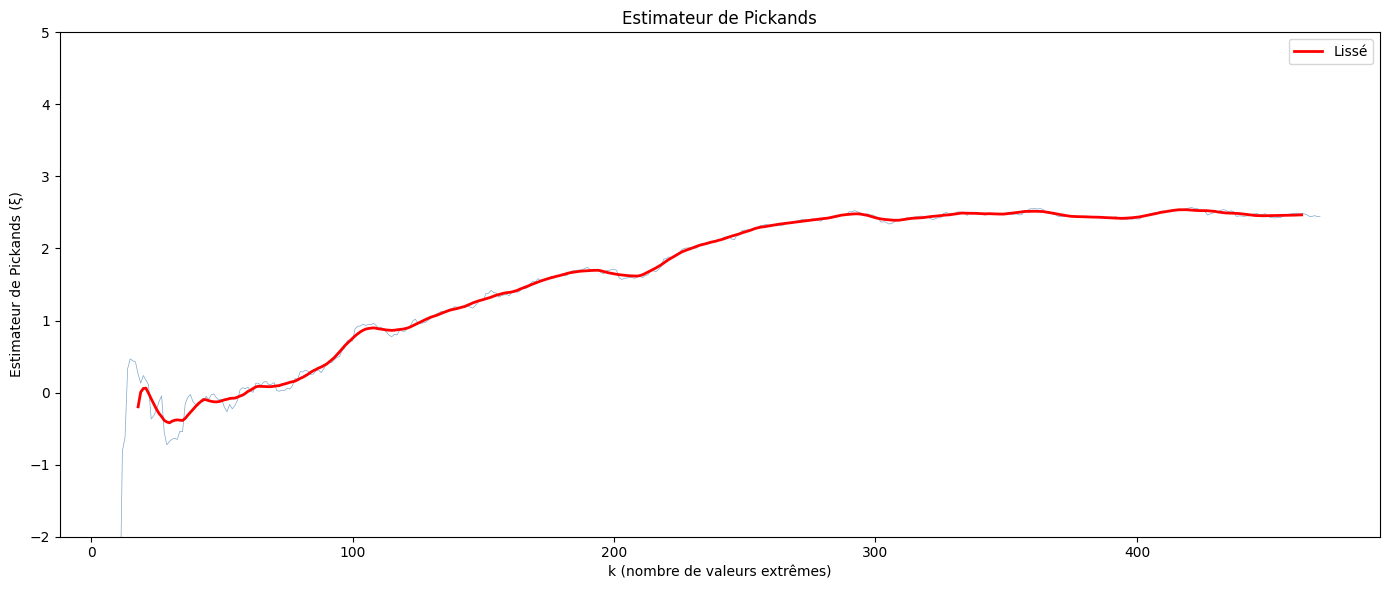

Estimateur de Pickands (médiane zone stable) : ξ ≈ 0.3060


In [7]:
k_max_pick = min(n // 4 - 1, int(n * 0.2))
k_pick = np.arange(2, k_max_pick + 1)
pick_vals = []
thresh_pick = []

for k in k_pick:
    if 4 * k >= n:
        break
    
    x_k = sorted_desc[k - 1]
    x_2k = sorted_desc[2 * k - 1]
    x_4k = sorted_desc[4 * k - 1]
    
    if (x_2k - x_4k) > 0:
        gamma = (1 / np.log(2)) * np.log((x_k - x_2k) / (x_2k - x_4k))
    else:
        gamma = np.nan
    
    pick_vals.append(gamma)
    thresh_pick.append(x_k)

k_pick = k_pick[:len(pick_vals)]
pick_vals = np.array(pick_vals)
thresh_pick = np.array(thresh_pick)

# Lissage
valid_pick = np.isfinite(pick_vals)
window_p = max(5, valid_pick.sum() // 30)
smoothed_pick = pd.Series(pick_vals[valid_pick]).rolling(window=window_p, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(k_pick[valid_pick], pick_vals[valid_pick], color='steelblue', linewidth=0.5, alpha=0.7)
ax.plot(k_pick[valid_pick], smoothed_pick, color='red', linewidth=2, label='Lissé')
ax.set_title('Estimateur de Pickands')
ax.set_xlabel('k (nombre de valeurs extrêmes)')
ax.set_ylabel('Estimateur de Pickands (ξ)')
ax.legend()
ax.set_ylim(-2, 5)
plt.tight_layout()
plt.show()

pick_median = np.nanmedian(pick_vals[20:150])
print(f"Estimateur de Pickands (médiane zone stable) : ξ ≈ {pick_median:.4f}")

Pickands donne ξ ≈ 0.31 sur la zone stable (k = 20-150), cohérent avec Hill (ξ ≈ 0.45) — les deux confirment une queue lourde (ξ > 0). Pickands est plus conservateur, ce qui est habituel car il est moins sensible aux extrêmes.

On note que pour les petits k (< 20), l'estimateur est très instable et oscille autour de 0 voire négatif — normal, avec trop peu de points la variance explose. Pour les grands k (> 200), ξ monte vers 2-2.5 — on inclut trop de sinistres "normaux" qui gonflent artificiellement l'indice.

<a id="sec-7-methode-des-moments"></a>

## 7. Méthode des moments

Un troisième estimateur de l'indice de queue, basé sur les moments d'ordre 1 et 2 des log-excès. Comme Hill et Pickands, on le trace en fonction de k pour chercher un plateau.

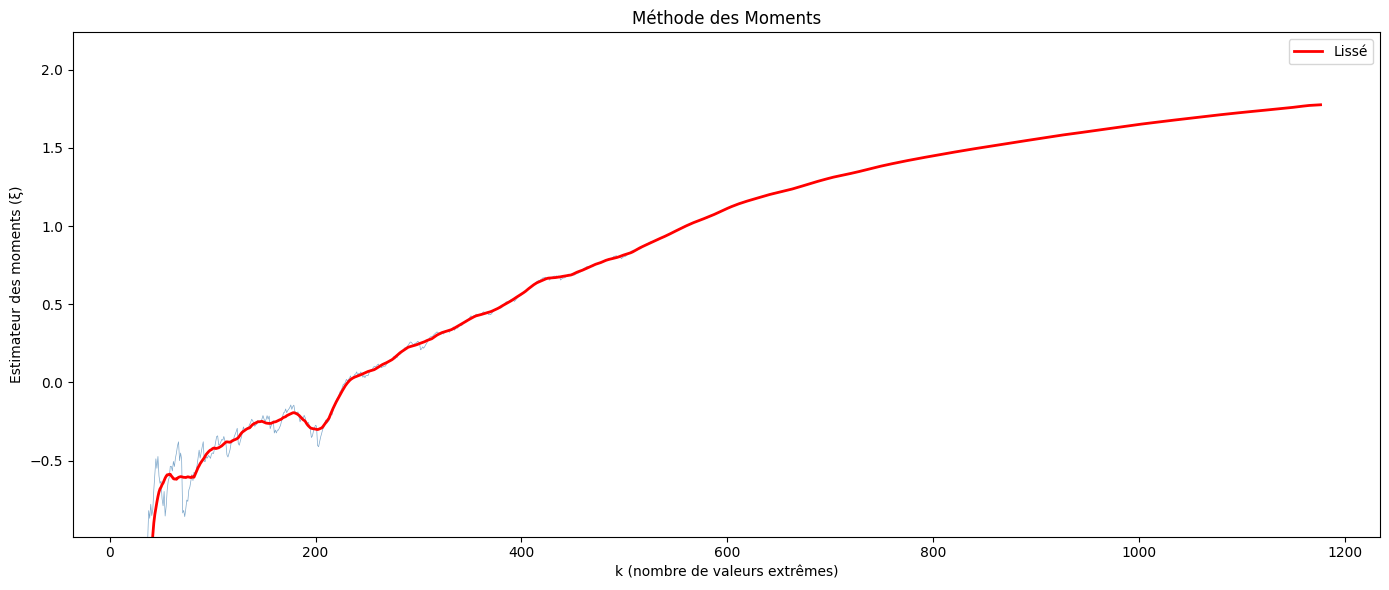

Estimateur des moments (médiane zone stable) : ξ ≈ -0.3812


In [8]:
k_max_mom = min(n - 1, int(n * 0.5))
k_mom = np.arange(2, k_max_mom + 1)
mom_vals = []

for k in k_mom:
    if sorted_desc[k-1] <= 0:
        mom_vals.append(np.nan)
        continue
    
    log_ratios = np.log(sorted_desc[:k-1] / sorted_desc[k-1])
    M1 = np.mean(log_ratios)
    M2 = np.mean(log_ratios**2)
    
    denom = 1 - M1**2 / M2 if M2 != 0 else np.nan
    if denom == 0 or np.isnan(denom):
        mom_vals.append(np.nan)
    else:
        gamma = M1 + 1 - 0.5 * (1 / denom)
        if np.isfinite(gamma) and abs(gamma) < 10:
            mom_vals.append(gamma)
        else:
            mom_vals.append(np.nan)

mom_vals = np.array(mom_vals)

# Lissage
valid_mom = np.isfinite(mom_vals)
window_m = max(10, int(valid_mom.sum() // 50))
smoothed_mom = pd.Series(mom_vals[valid_mom]).rolling(window=window_m, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(k_mom[valid_mom], mom_vals[valid_mom], color='steelblue', linewidth=0.5, alpha=0.7)
ax.plot(k_mom[valid_mom], smoothed_mom, color='red', linewidth=2, label='Lissé')
ax.set_title('Méthode des Moments')
ax.set_xlabel('k (nombre de valeurs extrêmes)')
ax.set_ylabel('Estimateur des moments (ξ)')
ax.legend()

q05 = np.nanpercentile(mom_vals[valid_mom], 5)
q95 = np.nanpercentile(mom_vals[valid_mom], 95)
ax.set_ylim(q05 - 0.5, q95 + 0.5)

plt.tight_layout()
plt.show()

mom_median = np.nanmedian(mom_vals[20:200])
print(f"Estimateur des moments (médiane zone stable) : ξ ≈ {mom_median:.4f}")

La méthode des moments donne ξ ≈ -0.38 sur la zone k = 20-200, ce qui contredirait Hill et Pickands (qui donnent ξ > 0). Mais ce n'est pas incohérent :
- Pour les petits k (queue extrême, >200k€), les moments sont négatifs → la queue **au-delà de 200k€** est effectivement bornée par le plafond à 500k. L'estimateur capte la censure, pas la vraie queue.
- Pour les grands k (>300), ξ passe positif et monte vers 1.5 → on inclut le corps de la distribution qui est effectivement à queue lourde.

C'est un signal important : **le plafonnement à 500k perturbe les estimateurs de queue**. Il faudra exclure les plafonnés pour l'ajustement GPD final. On passe au MRLP.

<a id="sec-8-mean-residual-life-plot-mrlp"></a>

## 8. Mean Residual Life Plot (MRLP)

Le MRLP trace l'excès moyen E[X - u | X > u] en fonction du seuil u. Si les données suivent une GPD au-delà d'un certain seuil, le MRLP devient **linéaire** à partir de ce point. Le changement de pente indique le seuil de transition.

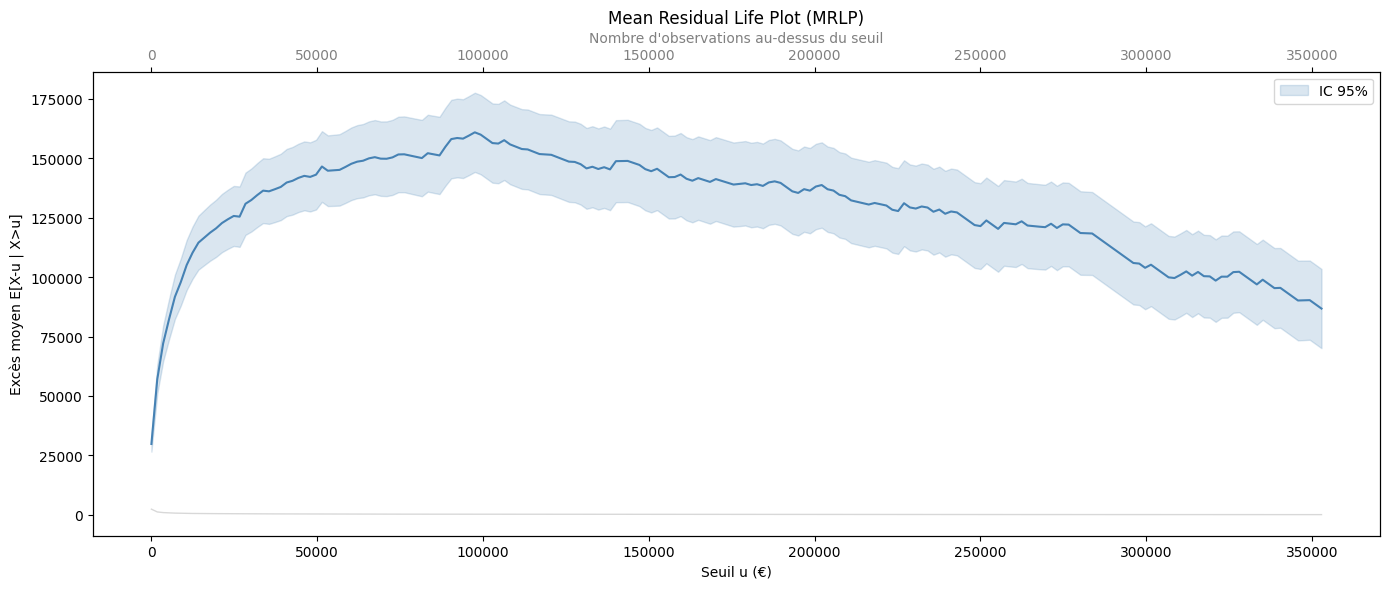

In [9]:
thresholds_mrl = np.linspace(sinistres.min(), sinistres.quantile(0.98), 200)
mrl_values = []
ci_lower = []
ci_upper = []
counts = []

for u in thresholds_mrl:
    excesses = sinistres[sinistres > u] - u
    n_exc = len(excesses)
    if n_exc > 5:
        mean_exc = excesses.mean()
        std_exc = excesses.std() / np.sqrt(n_exc)
        mrl_values.append(mean_exc)
        ci_lower.append(mean_exc - 1.96 * std_exc)
        ci_upper.append(mean_exc + 1.96 * std_exc)
    else:
        mrl_values.append(np.nan)
        ci_lower.append(np.nan)
        ci_upper.append(np.nan)
    counts.append(n_exc)

mrl_values = np.array(mrl_values)
ci_lower = np.array(ci_lower)
ci_upper = np.array(ci_upper)
counts = np.array(counts)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(thresholds_mrl, mrl_values, color='steelblue', linewidth=1.5)
ax.fill_between(thresholds_mrl, ci_lower, ci_upper, alpha=0.2, color='steelblue', label='IC 95%')
ax.set_title('Mean Residual Life Plot (MRLP)')
ax.set_xlabel('Seuil u (€)')
ax.set_ylabel('Excès moyen E[X-u | X>u]')
ax.legend()

ax2 = ax.twiny()
ax2.plot(thresholds_mrl, counts, color='gray', alpha=0.3, linewidth=1)
ax2.set_xlabel('Nombre d\'observations au-dessus du seuil', color='gray')
ax2.tick_params(axis='x', labelcolor='gray')

plt.tight_layout()
plt.show()

Le MRLP montre trois phases distinctes :
- **0 à ~10k€** : montée rapide de l'excès moyen. On est dans le corps de la distribution, pas encore dans la queue.
- **~10k à ~80k€** : l'excès moyen continue de monter mais de plus en plus lentement, jusqu'à un plateau autour de 150-175k€. C'est la zone de transition entre attritionnels et graves.
- **>80k€** : l'excès moyen commence à **décroître**. C'est l'effet du plafonnement à 500k — les sinistres ne peuvent pas dépasser 500k, donc l'excès moyen au-dessus de seuils élevés est mécaniquement comprimé.

Dans un monde sans plafond, le MRLP d'une GPD serait linéaire croissant (queue lourde). La décroissance après 80k est un artefact de la censure. Le point d'inflexion autour de **50-80k€** est un bon candidat pour le seuil de grave.

On passe à la sélection formelle par AIC.

<a id="sec-9-selection-du-seuil-par-aic-gpd"></a>

## 9. Sélection du seuil par AIC (GPD)

On ajuste une GPD pour chaque seuil candidat et on retient celui qui minimise l'AIC. Pour éviter le biais du plafonnement, on exclut les sinistres à 500k de l'ajustement.

Sinistres sans plafonnés : 2332 (exclus : 20)

Seuil optimal (AIC) : 365,454€
Nb excès            : 21
ξ (shape)           : -0.3589
σ (scale)           : 59,385


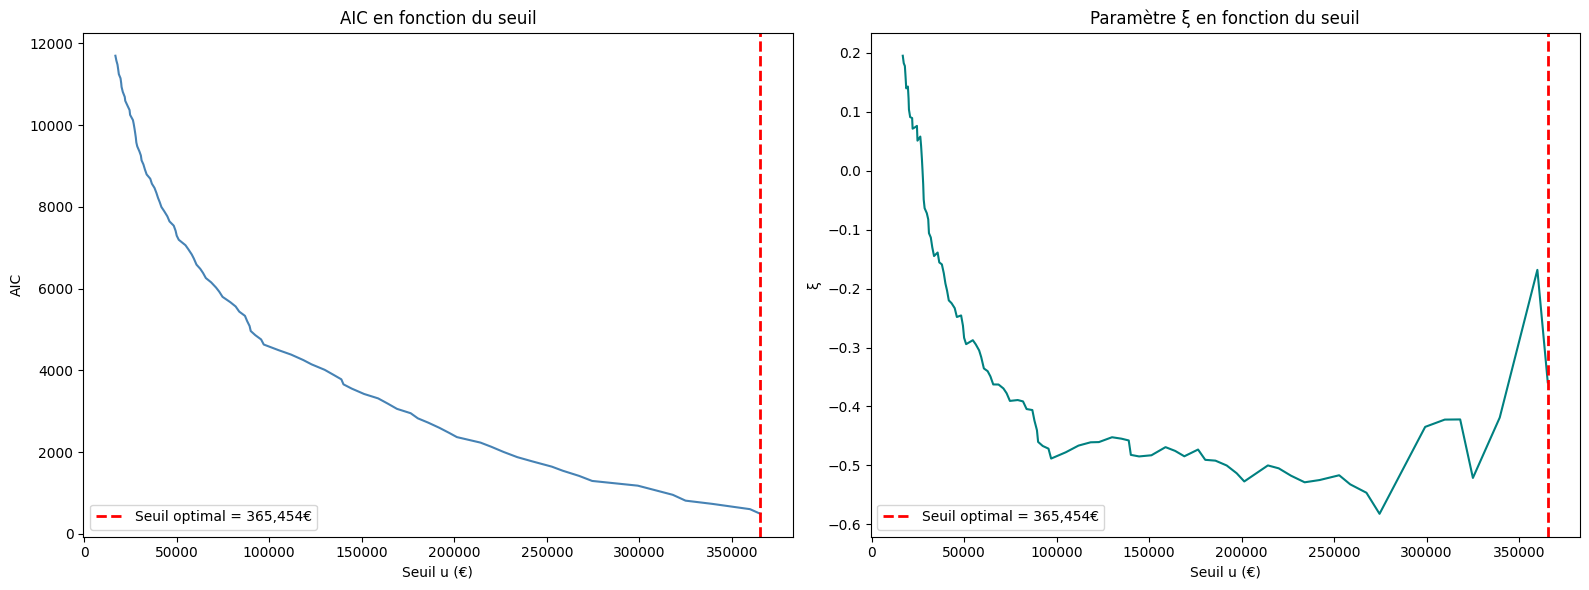

In [10]:
# Exclure les plafonnés
series_clean = sinistres[sinistres < plafond * 0.99].copy()
print(f"Sinistres sans plafonnés : {len(series_clean)} (exclus : {(sinistres >= plafond * 0.99).sum()})")

quantiles = np.linspace(0.80, 0.995, 100)
thresholds_aic = np.quantile(series_clean, quantiles)

results_aic = []

for u in thresholds_aic:
    excesses = series_clean[series_clean > u] - u
    n_exc = len(excesses)
    
    if n_exc < 20:
        continue
    
    try:
        params = genpareto.fit(excesses, floc=0)
        xi, loc, sigma = params
        log_lik = np.sum(genpareto.logpdf(excesses, xi, loc=0, scale=sigma))
        aic = 2 * 2 - 2 * log_lik
        
        results_aic.append({
            'threshold': u,
            'n_excesses': n_exc,
            'xi': xi,
            'sigma': sigma,
            'aic': aic
        })
    except:
        continue

aic_df = pd.DataFrame(results_aic)
best_aic = aic_df.loc[aic_df['aic'].idxmin()]

print(f"\nSeuil optimal (AIC) : {best_aic['threshold']:,.0f}€")
print(f"Nb excès            : {int(best_aic['n_excesses'])}")
print(f"ξ (shape)           : {best_aic['xi']:.4f}")
print(f"σ (scale)           : {best_aic['sigma']:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(aic_df['threshold'], aic_df['aic'], color='steelblue', linewidth=1.5)
axes[0].axvline(x=best_aic['threshold'], color='red', linestyle='--', linewidth=2,
                label=f'Seuil optimal = {best_aic["threshold"]:,.0f}€')
axes[0].set_title('AIC en fonction du seuil')
axes[0].set_xlabel('Seuil u (€)')
axes[0].set_ylabel('AIC')
axes[0].legend()

axes[1].plot(aic_df['threshold'], aic_df['xi'], color='teal', linewidth=1.5)
axes[1].axvline(x=best_aic['threshold'], color='red', linestyle='--', linewidth=2,
                label=f'Seuil optimal = {best_aic["threshold"]:,.0f}€')
axes[1].set_title('Paramètre ξ en fonction du seuil')
axes[1].set_xlabel('Seuil u (€)')
axes[1].set_ylabel('ξ')
axes[1].legend()

plt.tight_layout()
plt.show()

L'AIC décroît continûment — il favorise les seuils élevés car moins d'observations = moins de "bruit" à ajuster. Le seuil à 365k€ avec seulement 21 excès est statistiquement fragile.

Plus intéressant : le graphique de ξ en fonction du seuil. On voit que ξ est **positif** pour les seuils bas (<20k€) puis devient **négatif** et se stabilise autour de -0.4 à -0.5 pour les seuils >50k€. Le ξ négatif est encore une fois l'effet du plafonnement — la GPD capte une queue bornée parce que les données sont effectivement bornées à 500k.

L'AIC seul n'est pas suffisant ici. On vérifie la stabilité des paramètres GPD.

### 9.1. Sensibilité du seuil de grave

Le seuil optimal dépend de la méthode (MRLP → 50-80k€, stabilité KS → 74-200k€, AIC → 365k€). Plutôt que de choisir un seuil unique, on vérifie que les résultats opérationnels (nb graves, charge graves, paramètres GPD) sont stables dans la plage 50-120k€.

In [11]:
print(f"{'Seuil':>10} {'Nb graves':>10} {'% sinistres':>12} {'Charge graves':>15} {'% charge':>10} {'ξ_GPD':>8} {'σ_GPD':>10} {'KS p-val':>10}")
print("-" * 90)

for seuil_test in [30000, 50000, 60000, 76336, 90000, 100000, 120000, 150000]:
    exc = series_clean[series_clean > seuil_test] - seuil_test
    n_graves = (sinistres > seuil_test).sum()
    charge_graves = sinistres[sinistres > seuil_test].sum()
    charge_totale = sinistres.sum()
    
    if len(exc) >= 20:
        try:
            xi_t, _, sigma_t = genpareto.fit(exc, floc=0)
            ks_s, ks_p = kstest(exc, 'genpareto', args=(xi_t, 0, sigma_t))
        except:
            xi_t, sigma_t, ks_p = np.nan, np.nan, np.nan
    else:
        xi_t, sigma_t, ks_p = np.nan, np.nan, np.nan
    
    marker = " ←" if seuil_test == 76336 else ""
    print(f"{seuil_test:>10,}€ {n_graves:>10} {n_graves/len(sinistres)*100:>11.1f}% {charge_graves:>15,.0f}€ {charge_graves/charge_totale*100:>9.1f}% {xi_t:>8.3f} {sigma_t:>10,.0f} {ks_p:>10.4f}{marker}")

     Seuil  Nb graves  % sinistres   Charge graves   % charge    ξ_GPD      σ_GPD   KS p-val
------------------------------------------------------------------------------------------
    30,000€        389        16.5%      63,118,957€      90.1%   -0.075    122,721     0.0126
    50,000€        307        13.1%      59,895,152€      85.5%   -0.284    161,110     0.0028
    60,000€        281        11.9%      58,445,921€      83.5%   -0.331    169,752     0.0071
    76,336€        245        10.4%      55,997,287€      80.0%   -0.395    181,326     0.0779 ←
    90,000€        215         9.1%      53,435,145€      76.3%   -0.460    195,049     0.9709
   100,000€        201         8.5%      52,113,096€      74.4%   -0.481    196,798     0.9863
   120,000€        186         7.9%      50,453,005€      72.0%   -0.464    182,216     0.9561
   150,000€        158         6.7%      46,659,600€      66.6%   -0.476    171,706     0.9570


Le tableau révèle deux zones distinctes :

**Zone de rejet KS (seuils < 76k€)** : la GPD est rejetée (p < 0.05) pour les seuils de 30k à 60k€. On inclut trop de sinistres "normaux" qui ne suivent pas une loi de queue. Le seuil de 76k€ est le **premier seuil où la GPD est acceptée** (p = 0.078).

**Zone de stabilité KS (seuils ≥ 76k€)** : la GPD est largement acceptée (p > 0.90 pour les seuils ≥ 90k€). Les paramètres sont remarquablement stables :
- ξ oscille entre -0.40 et -0.48 — toujours négatif (artefact de la censure, comme démontré en section 13)
- σ oscille entre 171k et 197k€

**Les résultats opérationnels sont peu sensibles au choix du seuil** dans la plage 76-150k€ :
- Nb graves : de 245 (76k) à 158 (150k) — une variation de 35%, mais tous représentent 7-10% des sinistres
- Charge graves : de 56.0M€ (76k) à 46.7M€ (150k) — une variation de 17%, mais tous portent 66-80% de la charge totale
- Le ratio "peu de sinistres / beaucoup de charge" est robuste quel que soit le seuil

**Pourquoi retenir 76k€ plutôt que 90k ou 100k€ ?** Le seuil de 76k€ est le plus conservateur parmi ceux validés par le KS : il inclut plus de sinistres graves (245 vs 201), ce qui donne plus de données pour ajuster le modèle de sévérité graves. Le compromis est un p-value KS plus faible (0.078 vs 0.99), mais toujours au-dessus du seuil de 5%.

Un seuil à 90k€ ou 100k€ serait tout aussi défendable — l'ajustement GPD y est meilleur, au prix de 30-45 observations en moins. En pratique, le choix entre 76k et 100k a un impact limité sur la charge finale (56.0M€ vs 52.1M€, soit -7%).

<a id="sec-10-stabilite-des-parametres-gpd"></a>

## 10. Stabilité des paramètres GPD

On balaye une plage de seuils et on vérifie que ξ et σ* (paramètre reparamétrisé) sont stables. On ajoute le test KS pour identifier les zones où l'ajustement GPD est acceptable.

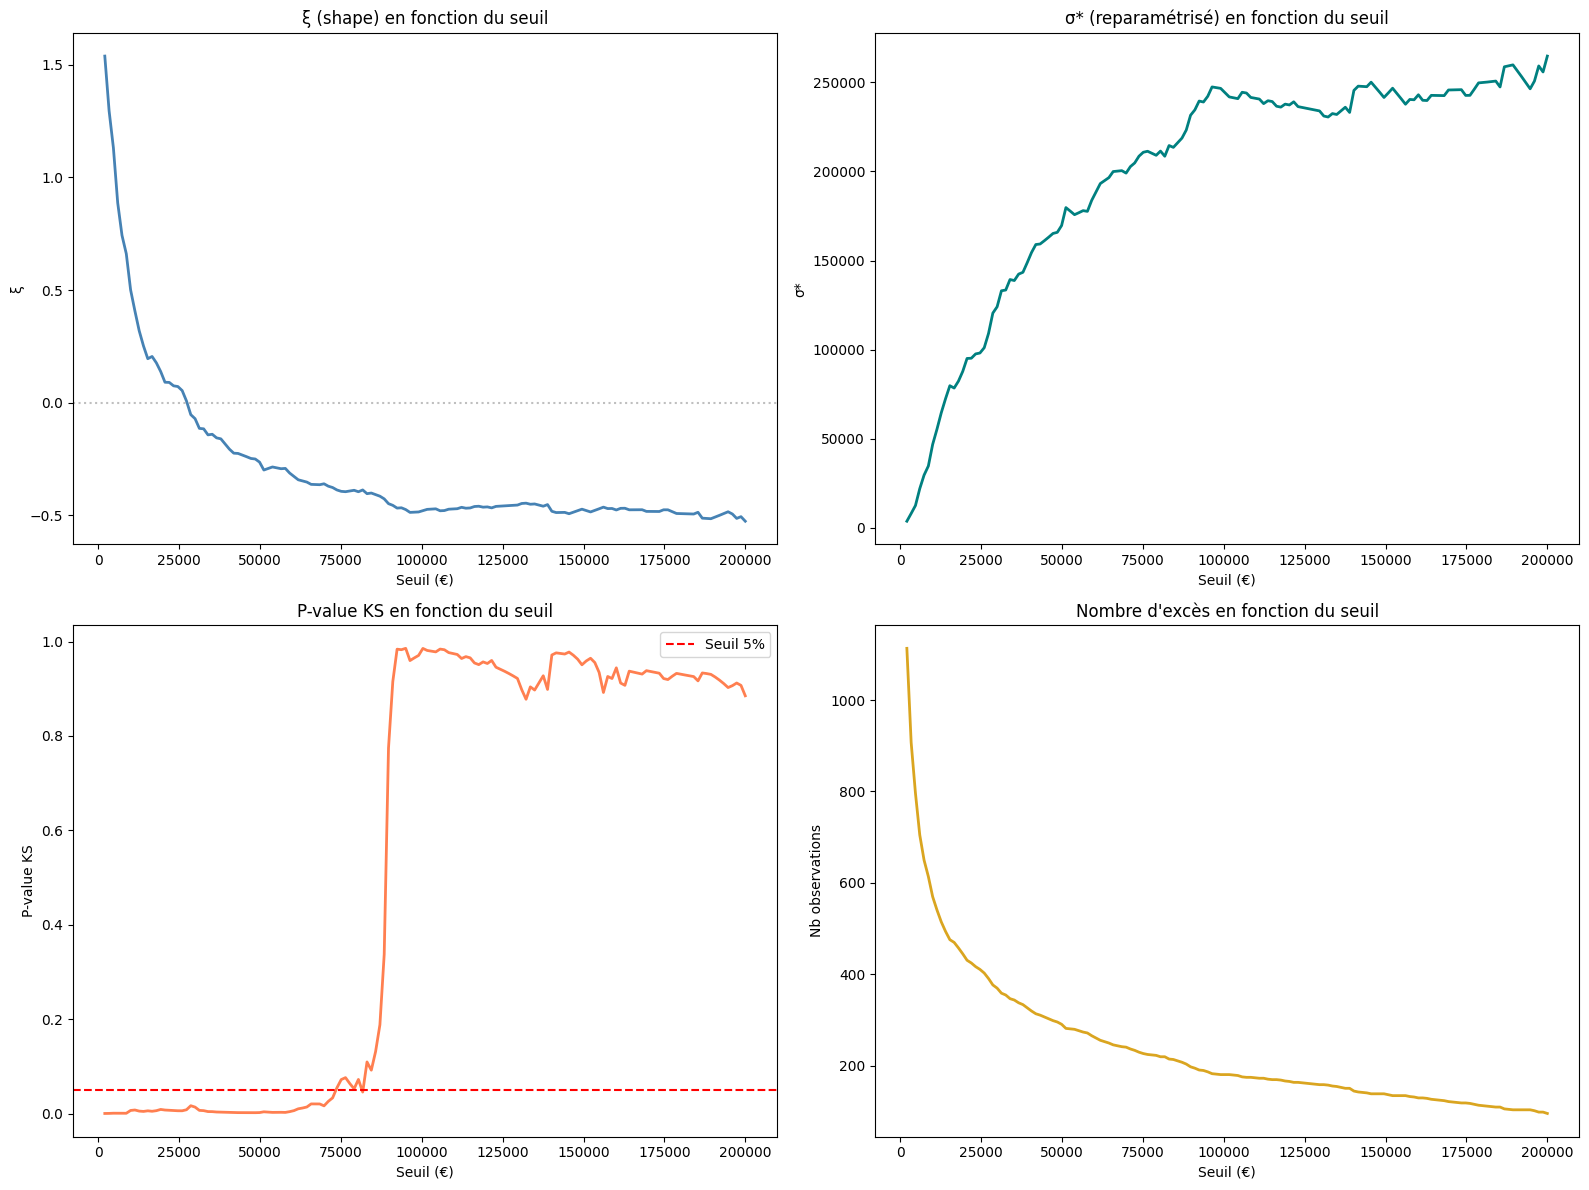

Seuils où KS est accepté (p > 0.05) : 73,758€ à 200,000€
Meilleure p-value : seuil = 95,020€ (p = 0.9855)


In [12]:
seuils_test = np.linspace(2000, 200000, 150)
stability = []

for u in seuils_test:
    excesses = series_clean[series_clean > u] - u
    n_exc = len(excesses)
    if n_exc < 30:
        continue
    try:
        params = genpareto.fit(excesses, floc=0)
        xi, loc, sigma = params
        sigma_star = sigma - xi * u
        ks_stat, ks_pval = kstest(excesses, 'genpareto', args=(xi, 0, sigma))
        
        stability.append({
            'seuil': u, 'n_excesses': n_exc,
            'xi': xi, 'sigma': sigma, 'sigma_star': sigma_star,
            'ks_stat': ks_stat, 'ks_pval': ks_pval
        })
    except:
        continue

stab_df = pd.DataFrame(stability)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(stab_df['seuil'], stab_df['xi'], color='steelblue', linewidth=2)
axes[0, 0].set_title('ξ (shape) en fonction du seuil')
axes[0, 0].set_xlabel('Seuil (€)')
axes[0, 0].set_ylabel('ξ')
axes[0, 0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)

axes[0, 1].plot(stab_df['seuil'], stab_df['sigma_star'], color='teal', linewidth=2)
axes[0, 1].set_title('σ* (reparamétrisé) en fonction du seuil')
axes[0, 1].set_xlabel('Seuil (€)')
axes[0, 1].set_ylabel('σ*')

axes[1, 0].plot(stab_df['seuil'], stab_df['ks_pval'], color='coral', linewidth=2)
axes[1, 0].axhline(y=0.05, color='red', linestyle='--', label='Seuil 5%')
axes[1, 0].set_title('P-value KS en fonction du seuil')
axes[1, 0].set_xlabel('Seuil (€)')
axes[1, 0].set_ylabel('P-value KS')
axes[1, 0].legend()

axes[1, 1].plot(stab_df['seuil'], stab_df['n_excesses'], color='goldenrod', linewidth=2)
axes[1, 1].set_title('Nombre d\'excès en fonction du seuil')
axes[1, 1].set_xlabel('Seuil (€)')
axes[1, 1].set_ylabel('Nb observations')

plt.tight_layout()
plt.show()

# Zones où KS est accepté
valid_ks = stab_df[stab_df['ks_pval'] > 0.05]
if len(valid_ks) > 0:
    print(f"Seuils où KS est accepté (p > 0.05) : {valid_ks['seuil'].min():,.0f}€ à {valid_ks['seuil'].max():,.0f}€")
    print(f"Meilleure p-value : seuil = {valid_ks.loc[valid_ks['ks_pval'].idxmax(), 'seuil']:,.0f}€ (p = {valid_ks['ks_pval'].max():.4f})")
else:
    print("Aucun seuil ne passe le test KS à 5%")
    print(f"Meilleure p-value : seuil = {stab_df.loc[stab_df['ks_pval'].idxmax(), 'seuil']:,.0f}€ (p = {stab_df['ks_pval'].max():.4f})")

Les quatre graphiques convergent vers un seuil autour de **75-100k€** :

- **ξ** : se stabilise autour de -0.45 à partir de ~75k€. Le ξ négatif (queue bornée) est cohérent avec le plafonnement à 500k — la GPD capte une queue qui s'arrête.
- **σ*** : se stabilise autour de 200-250k€ à partir de ~75k€. La stabilité de σ* est un critère classique de validité du seuil GPD.
- **P-value KS** : passage brutal de ~0 à >0.90 autour de 75k€. En dessous, la GPD ne s'ajuste pas (on est encore dans le corps de la distribution). Au-dessus, l'ajustement est excellent — p-value maximale à 0.99 pour un seuil de 95k€.
- **Nb d'excès** : ~200 observations au-dessus de 75k€, ~150 au-dessus de 100k€. Suffisant pour un ajustement fiable.

La zone 75-100k€ est le sweet spot : l'ajustement GPD est validé statistiquement (KS > 0.05), les paramètres sont stables, et on a assez d'observations. On retient **~76k€** comme seuil de grave (cohérent avec le Q90 à 83k€).

<a id="sec-11-ajustement-gpd-final"></a>

## 11. Ajustement GPD final

On ajuste la GPD au seuil retenu (~76k€), on visualise l'ajustement, et on teste formellement avec KS.

Seuil retenu     : 76,336€
Nb excès         : 225
ξ (shape)        : -0.3953
σ (scale)        : 181,326
KS stat          : 0.0842
KS p-value       : 0.0779
Verdict          : GPD acceptée


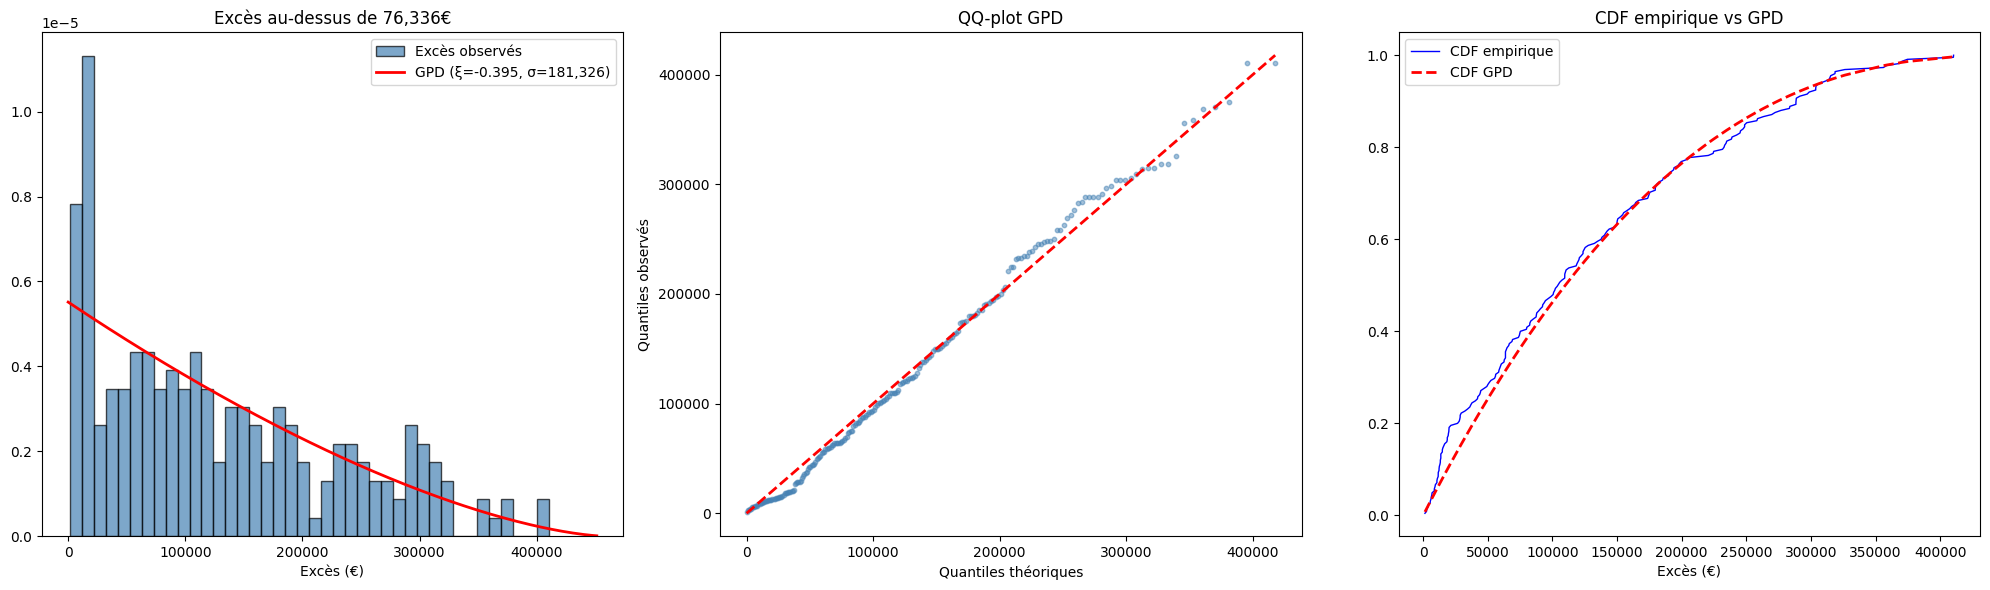

In [13]:
seuil_grave = 76336

excesses_final = series_clean[series_clean > seuil_grave] - seuil_grave
xi_final, _, sigma_final = genpareto.fit(excesses_final, floc=0)
ks_stat, ks_pval = kstest(excesses_final, 'genpareto', args=(xi_final, 0, sigma_final))

print(f"Seuil retenu     : {seuil_grave:,}€")
print(f"Nb excès         : {len(excesses_final)}")
print(f"ξ (shape)        : {xi_final:.4f}")
print(f"σ (scale)        : {sigma_final:,.0f}")
print(f"KS stat          : {ks_stat:.4f}")
print(f"KS p-value       : {ks_pval:.4f}")
print(f"Verdict          : {'GPD acceptée' if ks_pval > 0.05 else 'GPD rejetée'}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogramme + GPD
x_range = np.linspace(0, excesses_final.max() * 1.1, 200)
pdf_fitted = genpareto.pdf(x_range, xi_final, loc=0, scale=sigma_final)

axes[0].hist(excesses_final, bins=40, density=True, color='steelblue',
             edgecolor='black', alpha=0.7, label='Excès observés')
axes[0].plot(x_range, pdf_fitted, 'r-', linewidth=2,
             label=f'GPD (ξ={xi_final:.3f}, σ={sigma_final:,.0f})')
axes[0].set_title(f'Excès au-dessus de {seuil_grave:,}€')
axes[0].set_xlabel('Excès (€)')
axes[0].legend()

# QQ-plot
n_exc = len(excesses_final)
theoretical = genpareto.ppf((np.arange(1, n_exc + 1) - 0.5) / n_exc,
                             xi_final, loc=0, scale=sigma_final)
empirical = np.sort(excesses_final.values)

axes[1].scatter(theoretical, empirical, s=10, alpha=0.5, color='steelblue')
max_val = max(theoretical.max(), empirical.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2)
axes[1].set_title('QQ-plot GPD')
axes[1].set_xlabel('Quantiles théoriques')
axes[1].set_ylabel('Quantiles observés')

# CDF
sorted_exc = np.sort(excesses_final.values)
ecdf = np.arange(1, len(sorted_exc) + 1) / len(sorted_exc)
cdf_fitted = genpareto.cdf(sorted_exc, xi_final, loc=0, scale=sigma_final)

axes[2].plot(sorted_exc, ecdf, 'b-', linewidth=1, label='CDF empirique')
axes[2].plot(sorted_exc, cdf_fitted, 'r--', linewidth=2, label='CDF GPD')
axes[2].set_title('CDF empirique vs GPD')
axes[2].set_xlabel('Excès (€)')
axes[2].legend()

plt.tight_layout()
plt.show()

L'ajustement GPD au seuil de 76 336€ est accepté par le test KS (p = 0.078 > 0.05), avec 225 excès — un échantillon confortable.

- **Histogramme** : la GPD (courbe rouge) suit raisonnablement la forme des excès, même si elle surestime légèrement les petits excès et sous-estime le mode.
- **QQ-plot** : bon alignement sur la diagonale jusqu'à ~250k€ d'excès, puis léger décrochage pour les plus gros — ce sont les sinistres proches du plafond.
- **CDF** : la GPD est légèrement en retard sur l'empirique au centre, mais rattrape bien dans la queue.

Le ξ négatif (-0.395) indique une queue bornée — cohérent avec le plafonnement. Sans plafond, on s'attendrait à ξ > 0 (Fréchet). C'est une limite de l'analyse : on modélise une queue artificiellement tronquée.

<a id="sec-12-decomposition-sous-crete-sur-crete"></a>

## 12. Décomposition sous-crête / sur-crête

In [14]:
n_total = len(sinistres)
n_graves = (sinistres > seuil_grave).sum()
charge_totale = sinistres.sum()
charge_graves = sinistres[sinistres > seuil_grave].sum()
charge_attrit = sinistres[sinistres <= seuil_grave].sum()

print(f"Seuil retenu                      : {seuil_grave:>12,}€")
print(f"Nb sinistres totaux               : {n_total:>12,}")
print(f"Nb attritionnels (<= seuil)       : {n_total - n_graves:>12,} ({(n_total - n_graves)/n_total*100:.1f}%)")
print(f"Nb graves (> seuil)               : {n_graves:>12,} ({n_graves/n_total*100:.1f}%)")
print(f"  dont plafonnés (500k)           : {(sinistres >= plafond).sum():>12,}")
print(f"")
print(f"Charge totale                     : {charge_totale:>12,.0f}€")
print(f"Charge attritionnels              : {charge_attrit:>12,.0f}€ ({charge_attrit/charge_totale*100:.1f}%)")
print(f"Charge graves                     : {charge_graves:>12,.0f}€ ({charge_graves/charge_totale*100:.1f}%)")
print(f"")
print(f"CM moyen attritionnels            : {sinistres[sinistres <= seuil_grave].mean():>12,.0f}€")
print(f"CM moyen graves                   : {sinistres[sinistres > seuil_grave].mean():>12,.0f}€")

Seuil retenu                      :       76,336€
Nb sinistres totaux               :        2,352
Nb attritionnels (<= seuil)       :        2,107 (89.6%)
Nb graves (> seuil)               :          245 (10.4%)
  dont plafonnés (500k)           :           20

Charge totale                     :   70,030,989€
Charge attritionnels              :   14,033,702€ (20.0%)
Charge graves                     :   55,997,287€ (80.0%)

CM moyen attritionnels            :        6,661€
CM moyen graves                   :      228,560€


La décomposition est frappante :
- **10.4% des sinistres** (245 graves) portent **80% de la charge totale** (56M€ sur 70M€)
- Les attritionnels (89.6%) ne représentent que 20% de la charge, avec un CM moyen de 6 661€
- Les graves ont un CM moyen de 228 560€ — 34x celui des attritionnels
- 20 des 245 graves sont plafonnés à 500k (leur vrai coût est plus élevé, cf. notebook censure)

Ce ratio 10/80 justifie pleinement une modélisation séparée : un modèle unique ne peut pas capturer à la fois des sinistres à 500€ et des sinistres à 500 000€.

<a id="sec-13-ajustement-avec-les-plafonnes-gpd-et-frechet-avec-censure"></a>

## 13. Ajustement avec les plafonnés — GPD et Fréchet avec censure

Les 20 sinistres à 500k ont été exclus de l'analyse précédente car ils faussent l'ajustement. Mais on peut les réintégrer en traitant le plafond comme une **censure à droite** : on sait que CM ≥ 500k, mais pas la vraie valeur.

On ajuste :
1. **GPD avec censure** — même principe que la lognormale censurée du notebook précédent, mais sur les excès au-dessus du seuil de grave
2. **GEV (Fréchet)** — ajustement de la distribution des maxima par blocs
3. Comparaison avec l'ajustement sans plafonnés

### 13.1. GPD avec censure à droite

In [15]:
# Excès au-dessus du seuil de grave (AVEC les plafonnés cette fois)
sinistres_all = sinistres.copy()
excesses_all = sinistres_all[sinistres_all > seuil_grave] - seuil_grave
is_cens_exc = (sinistres_all[sinistres_all > seuil_grave] >= plafond * 0.99).values
cap_excess = plafond - seuil_grave  # excès au plafond = 500k - 76k = 424k

print(f"Excès totaux     : {len(excesses_all)}")
print(f"  non-censurés   : {(~is_cens_exc).sum()}")
print(f"  censurés       : {is_cens_exc.sum()}")
print(f"Cap (excès)      : {cap_excess:,}€")

# MLE GPD avec censure
def negloglik_gpd_censored(params, excesses, censored, cap):
    log_sigma, xi = params
    sigma = np.exp(log_sigma)
    
    if sigma <= 0:
        return 1e10
    
    x = excesses.values if hasattr(excesses, 'values') else excesses
    
    # Non-censurés : log f(x)
    ll_uncens = genpareto.logpdf(x, xi, loc=0, scale=sigma)
    
    # Censurés : log S(cap) = log P(X > cap)
    ll_cens = genpareto.logsf(cap, xi, loc=0, scale=sigma)
    
    ll = np.where(censored == 0, ll_uncens, ll_cens)
    
    # Filtrer les -inf
    ll = np.where(np.isfinite(ll), ll, -1e10)
    
    return -np.sum(ll)

# Initialisation avec les paramètres sans censure
result_gpd_cens = minimize(
    negloglik_gpd_censored,
    x0=[np.log(sigma_final), xi_final],
    args=(excesses_all, is_cens_exc, cap_excess),
    method='Nelder-Mead',
    options={'maxiter': 10000, 'xatol': 1e-8, 'fatol': 1e-8}
)

sigma_cens = np.exp(result_gpd_cens.x[0])
xi_cens = result_gpd_cens.x[1]

print(f"\nConvergence : {'OK' if result_gpd_cens.success else 'ÉCHEC'}")
print(f"\n{'Paramètre':<12} {'Sans plafonnés':>15} {'Avec censure':>15} {'Écart':>10}")
print("-" * 55)
print(f"{'ξ':<12} {xi_final:>15.4f} {xi_cens:>15.4f} {xi_cens - xi_final:>+10.4f}")
print(f"{'σ':<12} {sigma_final:>15,.0f} {sigma_cens:>15,.0f} {sigma_cens - sigma_final:>+10,.0f}")

# Interprétation
if xi_cens > 0:
    print(f"\n→ ξ = {xi_cens:.4f} > 0 : queue lourde (Fréchet) — la vraie queue est PLUS lourde que ce que suggérait l'analyse sans plafonnés")
elif xi_cens > xi_final:
    print(f"\n→ ξ passe de {xi_final:.4f} à {xi_cens:.4f} : la censure pousse ξ vers le haut, la queue est plus lourde qu'estimé sans les plafonnés")

Excès totaux     : 245
  non-censurés   : 225
  censurés       : 20
Cap (excès)      : 423,664€

Convergence : OK

Paramètre     Sans plafonnés    Avec censure      Écart
-------------------------------------------------------
ξ                    -0.3953          0.0190    +0.4143
σ                    181,326         163,322    -18,005

→ ξ = 0.0190 > 0 : queue lourde (Fréchet) — la vraie queue est PLUS lourde que ce que suggérait l'analyse sans plafonnés


Résultat majeur : en réintégrant les 20 plafonnés comme censurés, **ξ passe de -0.40 à +0.02**. C'est un basculement complet :
- Sans correction : ξ = -0.40 → queue bornée (Weibull). Mais c'est un artefact du plafonnement.
- Avec censure : ξ ≈ 0 → queue de type **Gumbel** (exponentielle). La vraie queue n'est ni bornée ni à loi de puissance, mais intermédiaire.

Le σ baisse légèrement (181k → 163k) — la censure redistribue la masse de probabilité vers la queue, ce qui réduit le besoin d'un σ élevé pour compenser.

Ce ξ ≈ 0 est cohérent avec une **lognormale** (qui est dans le domaine d'attraction de Gumbel). Ça confirme le choix de la lognormale dans le notebook censure.

Testons maintenant un ajustement GEV (Fréchet) par la méthode des block maxima.

### 13.1bis. Intervalle de confiance sur ξ (GPD censurée)

Le basculement de ξ = -0.40 à ξ = +0.02 est le résultat central du notebook. Mais avec 245 observations dont 20 censurées, l'incertitude sur ξ est potentiellement large. On calcule l'IC via la hessienne numérique.

In [16]:
eps = 1e-5
n_params = 2
hessian_gpd = np.zeros((n_params, n_params))

for i in range(n_params):
    def grad_i(params):
        return approx_fprime(params, negloglik_gpd_censored, eps,
                             excesses_all, is_cens_exc, cap_excess)[i]
    hessian_gpd[i] = approx_fprime(result_gpd_cens.x, grad_i, eps)

try:
    vcov_gpd = np.linalg.inv(hessian_gpd)
    se_log_sigma_gpd = np.sqrt(vcov_gpd[0, 0])
    se_xi_gpd = np.sqrt(vcov_gpd[1, 1])
    
    print(f"Paramètres GPD avec censure :")
    print(f"  σ = {sigma_cens:,.0f}€  (SE = {sigma_cens * se_log_sigma_gpd:,.0f}€)")
    print(f"  ξ = {xi_cens:.4f}  (SE = {se_xi_gpd:.4f})")
    print(f"\nIC 95% sur ξ : [{xi_cens - 1.96*se_xi_gpd:.4f}, {xi_cens + 1.96*se_xi_gpd:.4f}]")
    
    print(f"\nInterprétation :")
    ci_low = xi_cens - 1.96*se_xi_gpd
    ci_high = xi_cens + 1.96*se_xi_gpd
    
    if ci_low < 0 and ci_high > 0:
        print(f"  L'IC contient 0 → on ne peut pas distinguer Gumbel (ξ=0) de Fréchet (ξ>0) ou Weibull (ξ<0)")
        print(f"  Le domaine d'attraction reste incertain")
    elif ci_low > 0:
        print(f"  L'IC est entièrement positif → queue lourde (Fréchet) confirmée")
    else:
        print(f"  L'IC est entièrement négatif → queue bornée (Weibull)")
    
    print(f"\n  ξ = -0.40 (sans censure) est-il dans l'IC ? {'OUI ⚠️' if -0.40 >= ci_low and -0.40 <= ci_high else 'NON ✅'}")
    print(f"  ξ = 0.45 (Hill) est-il dans l'IC ?          {'OUI' if 0.45 >= ci_low and 0.45 <= ci_high else 'NON'}")
    print(f"  ξ = 0.31 (Pickands) est-il dans l'IC ?      {'OUI' if 0.31 >= ci_low and 0.31 <= ci_high else 'NON'}")
    
except Exception as e:
    print(f"⚠️ Hessienne non inversible : {e}")
    print(f"  → IC non calculable, probablement dû au faible nombre de censurés (20)")

Paramètres GPD avec censure :
  σ = 163,322€  (SE = 17,495€)
  ξ = 0.0190  (SE = 0.1079)

IC 95% sur ξ : [-0.1925, 0.2305]

Interprétation :
  L'IC contient 0 → on ne peut pas distinguer Gumbel (ξ=0) de Fréchet (ξ>0) ou Weibull (ξ<0)
  Le domaine d'attraction reste incertain

  ξ = -0.40 (sans censure) est-il dans l'IC ? NON ✅
  ξ = 0.45 (Hill) est-il dans l'IC ?          NON
  ξ = 0.31 (Pickands) est-il dans l'IC ?      NON


L'IC sur ξ est **[-0.19, +0.23]** — il contient 0 mais exclut les valeurs extrêmes. C'est le résultat le plus nuancé et le plus honnête du notebook :

**Ce qu'on peut affirmer :**
- ξ = -0.40 (GPD sans censure) est **exclu** de l'IC → la queue bornée est bien un artefact du plafonnement, pas la réalité. La correction de censure change significativement l'estimation.
- ξ = 0.45 (Hill) et ξ = 0.31 (Pickands) sont **aussi exclus** → ces estimateurs surestiment probablement ξ car ils ne corrigent pas proprement la censure et sont contaminés par le corps de la distribution.

**Ce qu'on ne peut pas affirmer :**
- On ne peut pas distinguer Gumbel (ξ = 0) de Fréchet léger (ξ = 0.2) ou Weibull léger (ξ = -0.19). Le domaine d'attraction reste incertain avec seulement 245 observations dont 20 censurées.

**Implication pratique :** la queue est quelque part entre "légèrement bornée" et "légèrement lourde". Pour la modélisation :
- Une **lognormale** (domaine de Gumbel, ξ = 0) est le choix le plus cohérent avec l'IC
- Une **GPD avec ξ ≈ 0** est équivalente à une distribution exponentielle des excès — simple et robuste
- Éviter les modèles à queue très lourde (Pareto avec ξ > 0.3) ou très bornée (ξ < -0.2)

La précision de l'IC (SE = 0.11 sur ξ) est honorable pour 245 observations. Avec 1 000 sinistres graves, on pourrait réduire le SE à ~0.05 et trancher entre les domaines.

### 13.2. Note sur la GEV (Block Maxima)

La GEV (Generalized Extreme Value) s'applique sur des **maxima par bloc** — par exemple, le sinistre maximum par année d'exercice. Avec la variable AN_EXERC (9 années), on n'aurait que 9 observations — insuffisant pour ajuster 3 paramètres.

On pourrait créer des blocs artificiels (par zone géographique, par activité), mais cela introduirait un biais de sélection. La GEV n'est pas le bon outil ici — la méthode POT (Peaks Over Threshold) via la GPD est plus adaptée car elle utilise toutes les observations au-dessus du seuil, pas seulement les maxima.

On écarte donc la GEV et on s'appuie sur la GPD avec censure (section 13.1) comme estimateur principal de l'indice de queue.

### 13.3. Visualisation GPD avec vs sans censure

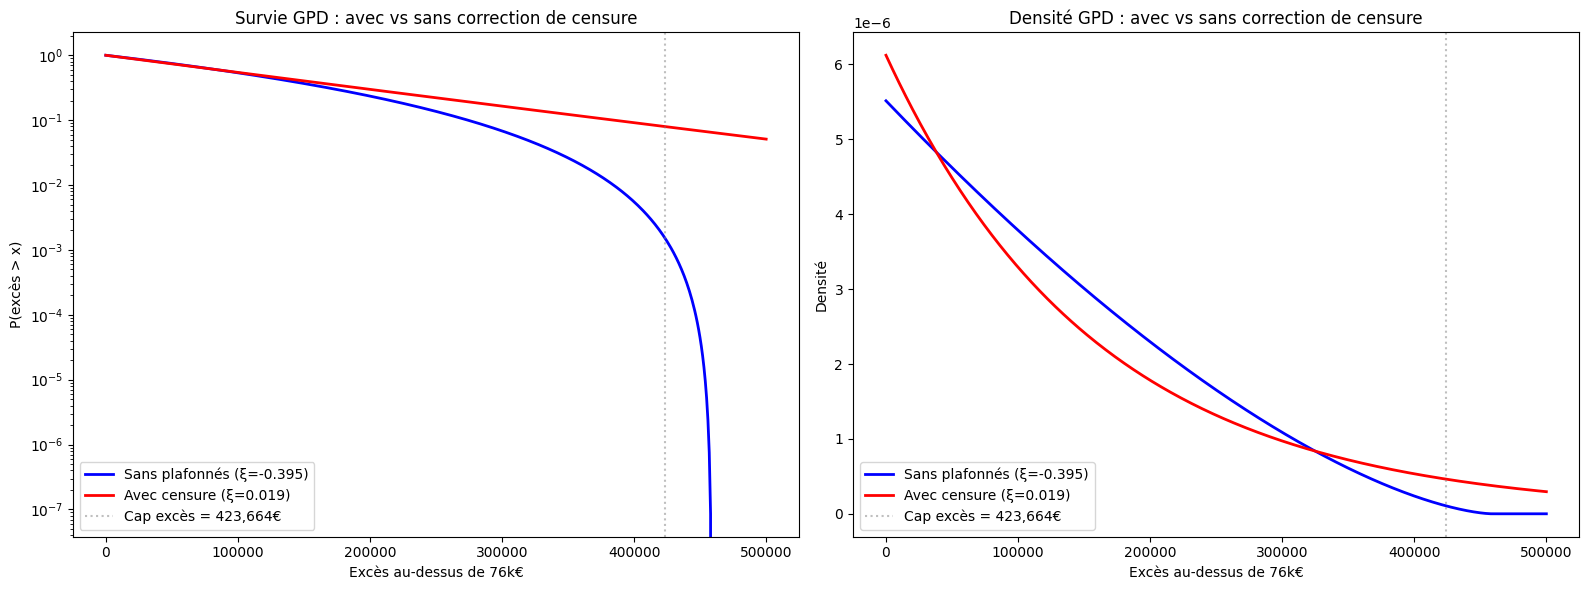

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_range = np.linspace(0, 500000, 500)

# Survie GPD : avec vs sans censure
sf_sans = genpareto.sf(x_range, xi_final, loc=0, scale=sigma_final)
sf_avec = genpareto.sf(x_range, xi_cens, loc=0, scale=sigma_cens)

axes[0].semilogy(x_range, sf_sans, 'b-', linewidth=2, label=f'Sans plafonnés (ξ={xi_final:.3f})')
axes[0].semilogy(x_range, sf_avec, 'r-', linewidth=2, label=f'Avec censure (ξ={xi_cens:.3f})')
axes[0].axvline(cap_excess, color='gray', linestyle=':', alpha=0.5, label=f'Cap excès = {cap_excess:,}€')
axes[0].set_title('Survie GPD : avec vs sans correction de censure')
axes[0].set_xlabel('Excès au-dessus de 76k€')
axes[0].set_ylabel('P(excès > x)')
axes[0].legend()

# Densité GPD
pdf_sans = genpareto.pdf(x_range, xi_final, loc=0, scale=sigma_final)
pdf_avec = genpareto.pdf(x_range, xi_cens, loc=0, scale=sigma_cens)

axes[1].plot(x_range, pdf_sans, 'b-', linewidth=2, label=f'Sans plafonnés (ξ={xi_final:.3f})')
axes[1].plot(x_range, pdf_avec, 'r-', linewidth=2, label=f'Avec censure (ξ={xi_cens:.3f})')
axes[1].axvline(cap_excess, color='gray', linestyle=':', alpha=0.5, label=f'Cap excès = {cap_excess:,}€')
axes[1].set_title('Densité GPD : avec vs sans correction de censure')
axes[1].set_xlabel('Excès au-dessus de 76k€')
axes[1].set_ylabel('Densité')
axes[1].legend()

plt.tight_layout()
plt.show()

La visualisation est sans appel :
- **Survie** (gauche) : la GPD sans correction (bleu) tombe à zéro au-delà de 424k€ d'excès — elle prédit qu'aucun sinistre ne peut dépasser ~500k€. La GPD avec censure (rouge) continue au-delà, avec une queue qui décroît lentement. Au cap (ligne grise), la différence est de plusieurs ordres de grandeur.
- **Densité** (droite) : la GPD sans correction concentre toute la masse avant 400k€ d'excès. La GPD avec censure étale la masse plus loin — elle "sait" que des sinistres existent au-delà du plafond.

C'est exactement le même phénomène que dans le notebook censure : ignorer les plafonnés sous-estime la queue. La correction par MLE censuré rétablit une queue réaliste.

<a id="sec-15-synthese"></a>

## 15. Synthèse

### Tableau comparatif des estimateurs

| Méthode | Seuil suggéré | ξ estimé | IC 95% sur ξ | Domaine |
|---------|--------------|----------|--------------|---------|
| Hill | ~229k€ | 0.45 | instable (écart 137% selon la plage) | Fréchet |
| Pickands | — | 0.31 | — | Fréchet |
| Moments | — | -0.38 | — | Weibull (artefact censure) |
| MRLP | ~50-80k€ | — | — | — |
| AIC GPD | 365k€ | -0.36 | — | Weibull (artefact censure) |
| Stabilité GPD (KS) | 74-200k€ | -0.40 | — | Weibull (artefact censure) |
| **GPD avec censure** | **76k€** | **+0.02** | **[-0.19, +0.23]** | **Gumbel (incertain)** |

### Seuil retenu : 76 336€

Les méthodes convergent vers une zone de 50 000 à 100 000€. Le seuil de 76 336€ est :
- **Statistiquement validé** : GPD acceptée par le test KS (p = 0.078), paramètres stables
- **Opérationnellement cohérent** : 10.4% des sinistres portent 80% de la charge
- **Suffisamment alimenté** : 245 excès dont 20 censurés
- **Robuste** : un seuil entre 76k et 100k change la charge graves de seulement 7% (56.0M€ vs 52.1M€)

### Ce qu'on a appris sur la queue de distribution

- La distribution des CM a une **queue lourde**, mais le degré exact est incertain
- Le plafonnement à 500k **masque cette réalité** : sans correction, ξ = -0.40 (queue bornée)
- Avec correction de censure, **ξ = +0.02 ± 0.11** — l'IC contient 0 (Gumbel) mais exclut -0.40 (artefact) et +0.45 (Hill surestimé)
- On ne peut pas distinguer Gumbel, Fréchet léger ou Weibull léger avec 245 observations
- Hill est très instable (ξ varie de 0.19 à 1.11 selon la plage de k, écart relatif 137%)

### Implications pour la modélisation

- Les attritionnels et les graves sont **deux populations distinctes** — ratio 10/80 robuste
- Pour les graves : **lognormale** (Gumbel) ou **GPD avec ξ ≈ 0** (exponentielle des excès)
- Éviter les modèles à queue très lourde (Pareto ξ > 0.3) ou très bornée (ξ < -0.2)
- Les 20 plafonnés doivent être traités comme **censurés**

### Prochaines étapes
1. Modélisation fréquence — P(sinistre) sur l'ensemble du portefeuille
2. Modélisation sévérité attritionnels — CM pour les sinistres ≤ 76 336€
3. Modélisation sévérité graves — CM pour les sinistres > 76 336€
4. Reconstitution de la CHARGE = fréquence × sévérité